# Análise exploratória dos anúncios do Airbnb em Santiago, Chile

**Cidade escolhida:** Santiago, Região Metropolitana de Santiago, Chile

**Perguntas de análise**
1. Como o preço de casas/apartamentos inteiros varia entre anúncios com e sem aquecimento e ar-condicionado?
2. As acomodações com anúncios mais caros também são as mais bem avaliadas?
3. Uma parcela pequena de anfitriões concentra uma grande parcela dos anúncios de Santiago?
4. Os anúncios localizados mais perto do centro de Santiago têm preço por pessoa mais alto?

## Carregamento e Estatísticas Básicas

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # will be used for the statistic test

sns.set_theme(style="whitegrid")

# listings from Santiago, Región Metropolitana de Santiago, Chile
datapath = "data/listings.csv"

df = pd.read_csv(datapath)  
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 18534 entries, 0 to 18533
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            18534 non-null  int64  
 1   listing_url                                   18534 non-null  str    
 2   scrape_id                                     18534 non-null  int64  
 3   last_scraped                                  18534 non-null  str    
 4   source                                        18534 non-null  str    
 5   name                                          18534 non-null  str    
 6   description                                   18141 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   18534 non-null  str    
 9   host_id                                       18534 non-null  int64  
 1

A célula acima carrega o conjunto de dados em um `DataFrame` e imprime alguns atributos sobre as colunas e os valores presentes. O conjunto de dados contém 18534 registros e 90 colunas. É possível notar que algumas colunas, como `host_since`, `neighbourhood`, e `instant_bookable`, estão completamente vazias. 

Abaixo, são identificadas as colunas com maior proporção de valores ausentes.

In [4]:
cols = df.columns
cols_nulls = df[cols].isnull()

cols_stats = pd.DataFrame({
    "qtd_ausentes": (cols_nulls.sum()),
    "%_ausentes": (cols_nulls.mean() * 100),
}).sort_values("%_ausentes")

cols_stats[cols_stats["qtd_ausentes"] > 0]

,qtd_ausentes,%_ausentes
minimum_maximum_nights,6,0.032373
minimum_minimum_nights,6,0.032373
maximum_maximum_nights,6,0.032373
minimum_nights,6,0.032373
maximum_nights,6,0.032373
maximum_minimum_nights,6,0.032373
bathrooms_text,17,0.091723
has_availability,226,1.219381
description,393,2.120427
price_quote_checkin_date,531,2.865005


É possível notar que a coluna `price` possui valores ausentes. Esses registros serão desconsiderados das análises que dependem do preço.

## Transformações e Variáveis Derivadas

A coluna `price` está em formato de texto (como `"$43,332.00"`). Foram removidos os caracteres `$` e `,` e então convertido o restante para o tipo `float`.

Variáveis derivadas: `price_accomodate`

In [5]:
price = "price"
accommodates = "accommodates"
price_accomodate = "price_accomodate"

# remove '$' and ',' from `price` and convert the remainder to float
df[price] = df[price].astype("string").str.replace(r"[$,]", "", regex=True).astype(float)

# other proccessings needed


# derived variables
df[price_accomodate] = df[price] / df[accommodates]

df[[price, accommodates, price_accomodate]]

,price,accommodates,price_accomodate
0,45647.0,2,22823.500000
1,19856.0,1,19856.000000
2,46776.0,3,15592.000000
3,25572.0,1,25572.000000
4,107043.5,3,35681.166667
...,...,...,...
18529,167533.0,4,41883.250000
18530,43492.5,6,7248.750000
18531,137380.0,6,22896.666667
18532,55192.5,2,27596.250000


In [6]:
print(f"{price} - Tendência Central e Medidas de Dispersão:")
df[price].describe()

price - Tendência Central e Medidas de Dispersão:


count    1.768800e+04
mean     1.181996e+05
std      1.226089e+06
min      9.786400e+02
25%      4.150000e+04
50%      5.900000e+04
75%      9.081375e+04
max      9.700004e+07
Name: price, dtype: float64

In [7]:
print(f"{price_accomodate} - Tendência Central e Medidas de Dispersão:")
df[price_accomodate].describe()

price_accomodate - Tendência Central e Medidas de Dispersão:


count    1.768800e+04
mean     4.093557e+04
std      5.141845e+05
min      7.998400e+02
25%      1.687500e+04
50%      2.284500e+04
75%      3.215307e+04
max      4.128347e+07
Name: price_accomodate, dtype: float64

In [8]:
prices = df[price].dropna()
mean, median, skew, p99 = prices.mean(), prices.median(), prices.skew(), prices.quantile(0.99)

skew_stats = pd.DataFrame({
    "media": mean,
    "mediana": median,
    "assimetria": skew,
    "p99": p99,
    "max": [df[price].max()],
}, index = [price])

print("Assimetria:")
skew_stats

Assimetria:


,media,mediana,assimetria,p99,max
price,118199.572537,59000.0,57.461838,686143.7071,97000045.0


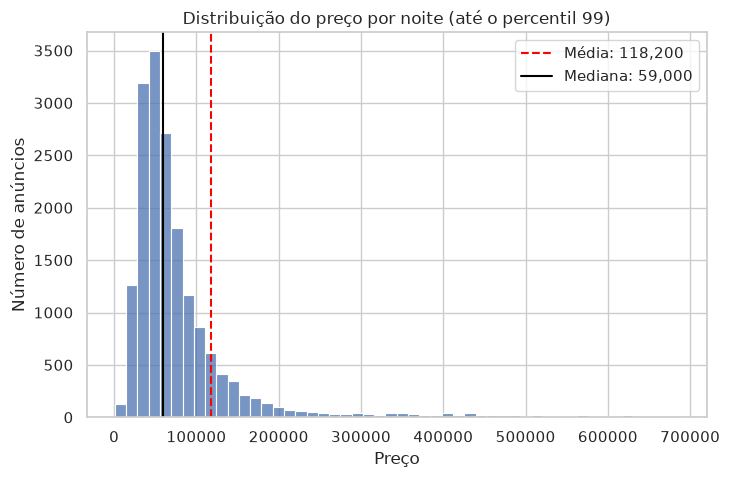

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(prices[prices <= p99], bins = 50, ax = ax)

ax.axvline(mean, color="red", linestyle="--", label=f"Média: {mean:,.0f}")
ax.axvline(median, color="black", linestyle="-", label=f"Mediana: {median:,.0f}")

ax.set_title("Distribuição do preço por noite (até o percentil 99)")
ax.set_xlabel("Preço")
ax.set_ylabel("Número de anúncios")
ax.legend()

plt.show()

Os preços são assimétricos à direita: a média (~118 mil CLP) é cerca de o dobro da mediana (59 mil CLP); a assimetria (`skew`) é positiva; e o valor máximo é aproximadamente 141 vezes o percentil 99, o que indica uma cauda longa de anúncios muito caros. 

Como a média é sensível a esses valores extremos e a mediana não, foi dada preferência à mediana para a construção de tabelas e visualizações.

### Amenidades como variáveis binárias

A coluna `amenities` é uma string JSON que representa uma lista de amenidades. Foram criadas colunas binárias representando as amenidades utilizadas nas visualizações.

**Amenidades**

| Coluna | Justificativa |
|---|---|
| `am_air_conditioner` | Santiago tem verões quentes e secos; é um diferencial de conforto. |
| `am_heating` | Os invernos são frios e muitas casas não têm calefação central. |


In [10]:

am_air_conditioner = "am_air_conditioner"
am_heating = "am_heating"

# find amenities that match with the terms used in the dataset
df[am_heating] = df["amenities"].str.contains(r"heating|heater|heat pump", case = False, na = False)
df[am_air_conditioner] = df["amenities"].str.contains(r"air condition|a/c", case = False, na = False)

group_temp = "group_temp"

# sets `group_temp` according to the amenities present
df[group_temp] = "Nenhum"
df.loc[df[am_heating] & ~df[am_air_conditioner], group_temp] = "Aquecimento"
df.loc[~df[am_heating] & df[am_air_conditioner], group_temp] = "Ar-condicionado"
df.loc[df[am_heating] & df[am_air_conditioner], group_temp] = "Ambos"

print(df[group_temp].value_counts())
print(df[group_temp].value_counts().sum() == len(df))

group_temp
Aquecimento        7588
Nenhum             5733
Ambos              4073
Ar-condicionado    1140
Name: count, dtype: int64
True


## Visualizações

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

sns.set_theme(style="whitegrid")

### Questão 1

**Filtros aplicados**

- Apenas anúncios com `room_type == "Entire home/apt"` (imóvel inteiro) foram considerados. Quartos compartilhados são um produto diferente e têm preços menores, o que poderia distorcer a comparação entre grupos de amenidades.

- Apenas anúncios com `price` não-nulo foram considerados.

**Grupos:** cada anúncio é classificado em um de quatro grupos, de acordo com as amenidades presentes: *Nenhum*, *Aquecimento*, *Ar-condicionado*, ou *Ambos*. Foram considerados aquecimento os itens "Heating", "Central heating", "Radiant heating", "Portable heater", "Heat pump" e "Heating - split type ductless system"; psicinas aquecidas e outros artigos de luxo foram desconsiderados.

**Agregação:** para cada grupo, `n` é o número de anúncios, `mediana` é a mediana do preço por noite, e `q1`/`q3` são o 1º e o 3º quartis. Usamos a mediana porque os preços são assimétricos à direita.

In [12]:
classes = ["Nenhum", "Aquecimento", "Ar-condicionado", "Ambos"]
entire_homes = df[(df["room_type"] == "Entire home/apt") & df[price].notna()]

price_group = entire_homes.groupby(group_temp)[price]

tab_q1 = pd.DataFrame({
    "n": price_group.count(),
    "mediana": price_group.median(),
    "q1": price_group.quantile(0.25),
    "q3": price_group.quantile(0.75),
})

tab_q1 = tab_q1.reindex(classes)
tab_q1

,n,mediana,q1,q3
group_temp,,,,
Nenhum,3803,52115.000,41019.0,71323.75
Aquecimento,6266,66187.335,46831.5,102706.00
Ar-condicionado,845,69517.000,51353.0,98800.00
Ambos,3511,79119.000,58480.5,112774.50


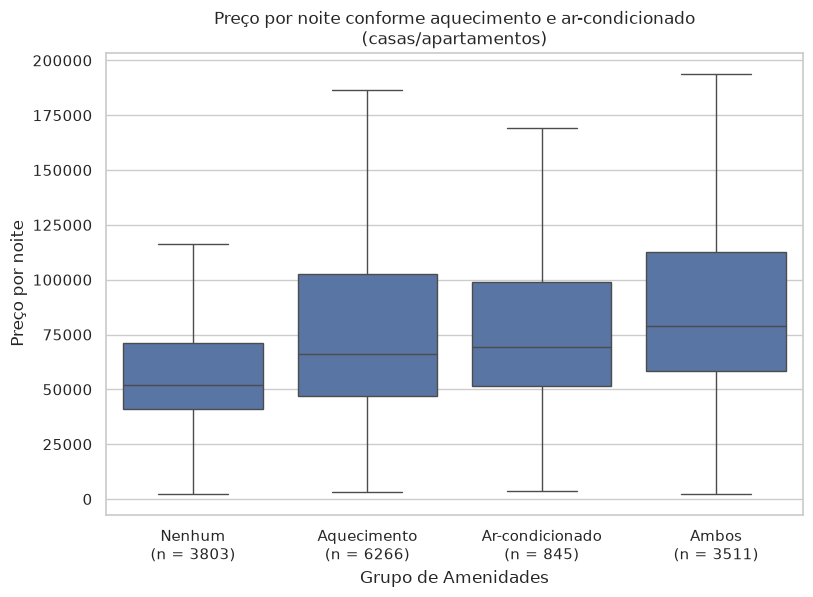

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

# needs to remove outliers ("fliers") since there are quite a lot of luxury houses 
sns.boxplot(data = entire_homes, x = group_temp, y = price, order = classes, showfliers = False, ax = ax)

# maybe log scale?
# ax.set_yscale("log")
ax.set_xticks(range(len(classes)))
ax.set_xticklabels([f"{c}\n(n = {tab_q1.loc[c, 'n']})" for c in classes])
ax.set_title("Preço por noite conforme aquecimento e ar-condicionado\n(casas/apartamentos)")
ax.set_xlabel("Grupo de Amenidades")
ax.set_ylabel("Preço por noite")

plt.show()

### Questão 2

**Pergunta:** Uma parcela pequena de anfitriões concentra uma grande parcela dos anúncios de Santiago?

**Filtros aplicados**

- Todos os anúncios da base foram considerados, de qualquer tipo de acomodação, pois a pergunta é sobre a estrutura do mercado como um todo.

- Apenas anúncios com `host_id` não-nulo.

**Variáveis:** o anfitrião é identificado por `host_id`, que representa uma conta, não necessariamente uma pessoa. Uma empresa pode operar com várias contas, então a concentração real pode ser maior que a observada.

**Agregação:** agrupando por `host_id`, `anuncios_por_anfitriao` é o número de anúncios de cada anfitrião. Na primeira tabela, os anfitriões são divididos em faixas (1, 2 a 5, 6 a 10 e 11 ou mais anúncios), e para cada faixa são mostrados o número de anfitriões, o número de anúncios e o percentual de cada um sobre o total. Na segunda tabela, os anfitriões são ordenados do maior para o menor, e mostra-se qual percentual dos anúncios é detido pelos 1%, 5% e 10% maiores.

In [17]:
import numpy as np

host_id = "host_id"

base_q3 = df[df[host_id].notna()]

# Número de anúncios de cada anfitrião
listings_per_host = base_q3.groupby(host_id).size()

total_hosts = len(listings_per_host)
total_listings = listings_per_host.sum()

# Tabela 1: anfitriões divididos em faixas
host_band = pd.cut(
    listings_per_host,
    bins = [0, 1, 5, 10, np.inf],
    labels = ["1", "2 a 5", "6 a 10", "11 ou mais"],
)

tab_q3 = pd.DataFrame({
    "n_anfitrioes": listings_per_host.groupby(host_band, observed = False).count(),
    "n_anuncios": listings_per_host.groupby(host_band, observed = False).sum(),
})
tab_q3["%_anfitrioes"] = tab_q3["n_anfitrioes"] / total_hosts * 100
tab_q3["%_anuncios"] = tab_q3["n_anuncios"] / total_listings * 100

print(f"Anfitriões: {total_hosts} | Anúncios: {total_listings}")
tab_q3

Anfitriões: 9712 | Anúncios: 18534


,n_anfitrioes,n_anuncios,%_anfitrioes,%_anuncios
1,7264,7264,74.794069,39.192835
2 a 5,2013,5253,20.726936,28.342506
6 a 10,269,2000,2.769769,10.790979
11 ou mais,166,4017,1.709226,21.673681


In [18]:
sorted_counts = listings_per_host.sort_values(ascending = False)

percents = [0.01, 0.05, 0.10]
rows = []

for i in range(len(percents)):
    p = percents[i]
    k = int(round(total_hosts * p))
    listings_top = sorted_counts.iloc[:k].sum()
    rows.append({
        "maiores_anfitrioes": f"{p * 100:.0f}%",
        "n_anfitrioes": k,
        "n_anuncios": listings_top,
        "%_anuncios": listings_top / total_listings * 100,
    })

tab_top = pd.DataFrame(rows)
tab_top

,maiores_anfitrioes,n_anfitrioes,n_anuncios,%_anuncios
0,1%,97,3153,17.011978
1,5%,486,6272,33.840509
2,10%,971,8097,43.687277


O gráfico abaixo é um histograma do número de anúncios por anfitrião. O eixo x mostra a quantidade de anúncios que um anfitrião possui, e o eixo y mostra quantos anfitriões estão naquele valor. O eixo y está em **escala logarítmica**, pois a grande maioria dos anfitriões tem poucos anúncios e uma pequena cauda tem muitos, portanto, em uma escala linear, as barras da cauda não seriam visíveis. 

Cada barra tem largura 1, ou seja, representa exatamente um valor de número de anúncios. As linhas verticais marcam a mediana e a média, e a distância entre elas já indica a assimetria da distribuição.

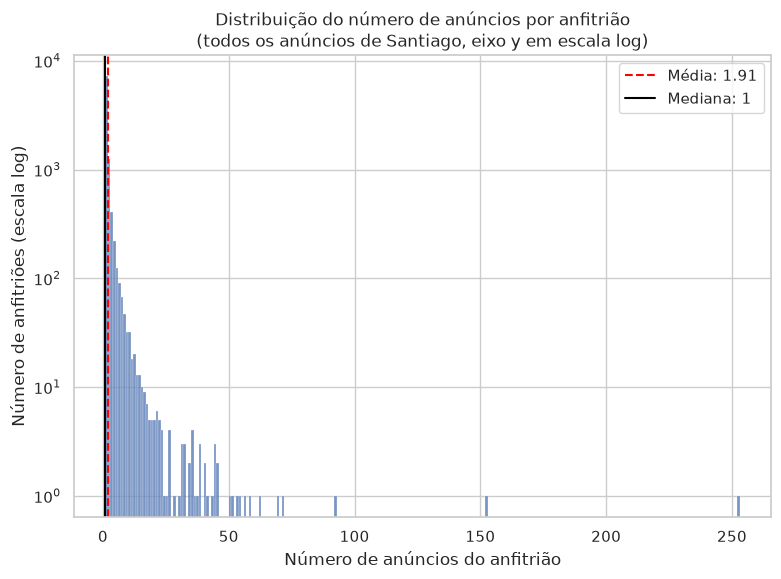

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.histplot(listings_per_host, binwidth = 1, ax = ax)

ax.set_yscale("log")

median_hosts = listings_per_host.median()
mean_hosts = listings_per_host.mean()

ax.axvline(mean_hosts, color = "red", linestyle = "--", label = f"Média: {mean_hosts:.2f}")
ax.axvline(median_hosts, color = "black", linestyle = "-", label = f"Mediana: {median_hosts:.0f}")

ax.set_title("Distribuição do número de anúncios por anfitrião\n(todos os anúncios de Santiago, eixo y em escala log)")
ax.set_xlabel("Número de anúncios do anfitrião")
ax.set_ylabel("Número de anfitriões (escala log)")
ax.legend()

plt.show()

Os resultados mostram que a maioria dos anfitriões de Santiago tem apenas 1 anúncio (74,8% dos anfitriões), mas eles detêm 39,2% dos anúncios. Na outra ponta, os 166 anfitriões da faixa "11 ou mais" (1,7% do total) detêm 21,7% dos anúncios. Somando as duas faixas profissionais (6 anúncios ou mais), 4,5% dos anfitriões concentram cerca de 32,5% dos anúncios. 

A concentração aparece também no recorte pelos maiores anfitriões: os 1% maiores (97 anfitriões) detêm 17,0% dos anúncios, os 5% maiores detêm 33,8% e os 10% maiores (971 anfitriões) detêm 43,7%, ou seja, mais de quatro vezes a sua participação no número de anfitriões. A média (1,91) maior que a mediana (1) confirma a assimetria à direita, e o gráfico mostra casos isolados com cerca de 90, 150 e 250 anúncios.

Isso sugere que o mercado de Santiago é moderadamente concentrado, pois uma parcela pequena de anfitriões concentra uma parcela grande, mas o mercado não é dominado por eles, pois os anfitriões individuais ainda detêm a maior fatia isolada dos anúncios (39,2%).

**Ressalvas:** `host_id` identifica uma conta, e um mesmo grupo pode operar várias contas, então a concentração real tende a ser maior que a observada. A análise conta anúncios, não receita nem reservas, então um anfitrião com muitos anúncios pouco ativos pesa mais aqui do que na demanda real. 

### Questão 3

**Pergunta:** Os anúncios localizados mais perto do centro de Santiago têm preço por pessoa mais alto?

**Filtros aplicados**

- Apenas anúncios com `room_type == "Entire home/apt"`, pelo mesmo motivo da Questão 1.

- Apenas anúncios com `price_accomodate`, `latitude` e `longitude` não-nulos.

**Variáveis:** "centro" foi definido como a Plaza de Armas (latitude -33,4378 e longitude -70,6504), uma escolha deste trabalho. A distância de cada anúncio ao centro (`dist_centro_km`) foi calculada em linha reta, em quilômetros, com a fórmula de Haversine.

**Agregação:** na tabela, os anúncios são divididos em faixas de distância (0 a 2 km, 2 a 5 km, 5 a 10 km e 10 km ou mais). Para cada faixa, `n` é o número de anúncios e `mediana_preco_pessoa` é a mediana do preço por noite dividido pela capacidade. Usamos a mediana porque o preço é assimétrico à direita.

**Teste estatístico:** a relação é medida com a correlação de Spearman entre a distância e o preço por pessoa.
- H0: não há associação monotônica entre a distância ao centro e o preço.
- H1: há associação monotônica.

Escolhemos o Spearman porque o preço é muito assimétrico e a relação pode não ser linear. Como comparação, também foi calculado o Pearson entre a distância e o logaritmo do preço.

In [20]:
import numpy as np

lat = "latitude"
lon = "longitude"
dist = "dist_centro_km"

# Ponto de referência: Plaza de Armas
center_lat = -33.4378
center_lon = -70.6504
earth_radius_km = 6371

# Distância em linha reta entre dois pontos na Terra.
lat1 = np.radians(df[lat])
lon1 = np.radians(df[lon])
lat2 = np.radians(center_lat)
lon2 = np.radians(center_lon)

dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
df[dist] = 2 * earth_radius_km * np.arcsin(np.sqrt(a))

df[dist].describe()

count    18534.000000
mean         5.336928
std          6.758339
min          0.044048
25%          1.473357
50%          3.405674
75%          6.599682
max         40.985825
Name: dist_centro_km, dtype: float64

In [21]:
reviews = "number_of_reviews_ltm"
log_price = "log_price_accomodate"

q2_dist_base = df[
    (df["room_type"] == "Entire home/apt")
    & df[price_accomodate].notna()
    & df[dist].notna()
].copy()

# Logaritmo na base 10 do preço, usado no gráfico e na correlação de Pearson
q2_dist_base[log_price] = np.log10(q2_dist_base[price_accomodate])

# Faixas de distância
bands = ["0 a 2 km", "2 a 5 km", "5 a 10 km", "10 km ou mais"]
dist_band = pd.cut(q2_dist_base[dist], bins = [0, 2, 5, 10, np.inf], labels = bands, include_lowest = True)

band_group = q2_dist_base.groupby(dist_band, observed = False)

tab_q2_dist = pd.DataFrame({
    "n": band_group[price_accomodate].count(),
    "mediana_preco_pessoa": band_group[price_accomodate].median(),
})

tab_q2_dist

,n,mediana_preco_pessoa
dist_centro_km,,
0 a 2 km,5201,18750.000
2 a 5 km,4591,23108.750
5 a 10 km,3272,28762.000
10 km ou mais,1361,45933.333


In [22]:
# Correlação de Spearman entre distância e preço por pessoa
rho_price, p_price = stats.spearmanr(q2_dist_base[dist], q2_dist_base[price_accomodate])

# Correlação de Pearson entre distância e logaritmo do preço por pessoa (para comparação)
r_log, p_log = stats.pearsonr(q2_dist_base[dist], q2_dist_base[log_price])

# Apenas anúncios com pelo menos uma avaliação nos últimos 12 meses
q2_dist_active = q2_dist_base[q2_dist_base[reviews] > 0]
rho_rev, p_rev = stats.spearmanr(q2_dist_active[dist], q2_dist_active[reviews])

print(f"Preço por pessoa (n = {len(q2_dist_base)})")
print(f"Spearman: {rho_price:.3f} (p = {p_price:.4f})")
print(f"Pearson com log do preço: {r_log:.3f} (p = {p_log:.4f})")

Preço por pessoa (n = 14425)
Spearman: 0.433 (p = 0.0000)
Pearson com log do preço: 0.513 (p = 0.0000)


**O resultado depende dos anúncios mais distantes?**

O gráfico mostra um grupo de anúncios entre 33 e 40 km do centro, com preços por pessoa mais altos, que puxa a reta de regressão para cima. Para verificar se a correlação observada depende apenas desse grupo, o Spearman foi recalculado considerando somente os anúncios a menos de 20 km da Plaza de Armas. A hipótese nula e a alternativa são as mesmas da análise principal. Se a correlação continuar positiva e relevante, o resultado não é explicado apenas pelos anúncios mais afastados.

In [23]:
near = q2_dist_base[q2_dist_base[dist] < 20]
rho_near, p_near = stats.spearmanr(near[dist], near[price_accomodate])

print(f"Menos de 20 km (n = {len(near)})")
print(f"  Spearman: {rho_near:.3f} (p = {p_near:.4f})")

Menos de 20 km (n = 13800)
  Spearman: 0.359 (p = 0.0000)


**Quem são os anúncios a 30 km ou mais do centro?**

Para identificar o grupo isolado que aparece no gráfico, foram selecionados os anúncios a 30 km ou mais da Plaza de Armas e agrupados por `neighbourhood_cleansed`. Para cada comuna, `n` é o número de anúncios, `mediana_preco_pessoa` é a mediana do preço por pessoa por noite e `dist_media_km` é a distância média ao centro.

In [24]:
far = q2_dist_base[q2_dist_base[dist] >= 30]

far_group = far.groupby("neighbourhood_cleansed")

tab_far = pd.DataFrame({
    "n": far_group[price_accomodate].count(),
    "mediana_preco_pessoa": far_group[price_accomodate].median(),
    "dist_media_km": far_group[dist].mean(),
})

tab_far.sort_values("n", ascending = False)

,n,mediana_preco_pessoa,dist_media_km
neighbourhood_cleansed,,,
Lo Barnechea,592,77127.630952,35.758842


Abaixo de 20 km (n = 13.800), o Spearman é 0,359 (p < 0,001), menor que o valor geral (0,433), mas ainda positivo e moderado. A tabela mostra que todos os 592 anúncios a 30 km ou mais pertencem a uma única comuna, Lo Barnechea, com mediana de 77.128 CLP por pessoa e distância média de 35,8 km. Esse grupo representa cerca de 43% dos anúncios da faixa "10 km ou mais" e reforça a relação, mas não é a única causa dela.

**Gráfico**

O gráfico abaixo é uma dispersão com um ponto por anúncio. O eixo x mostra a distância ao centro (km) e o eixo y mostra o preço por pessoa por noite, em escala logarítmica (log10), porque o preço é muito assimétrico, e em escala linear, quase todos os pontos ficariam amontoados na base. 

Os valores originais aparecem nos rótulos do eixo. Os pontos são semitransparentes para mostrar onde há mais anúncios, e a linha vermelha é uma reta de regressão sobre o log do preço, que resume a tendência geral.

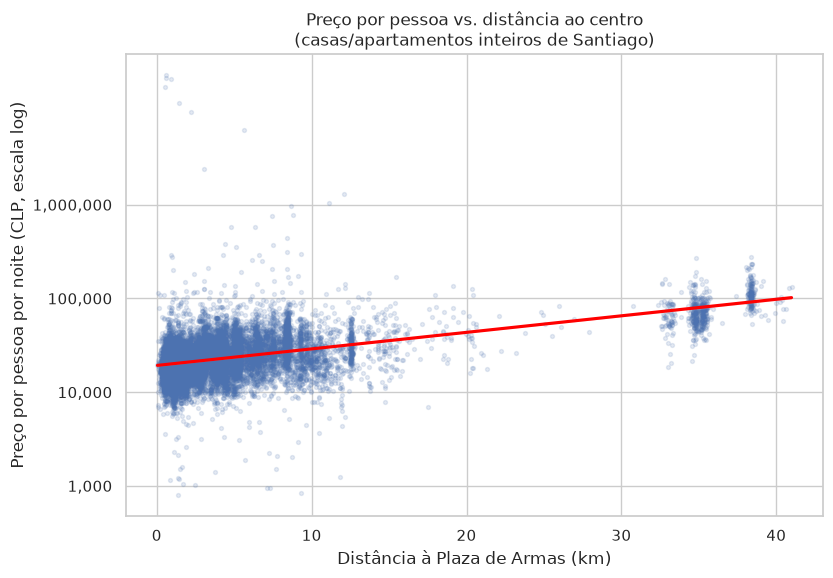

In [25]:
fig, ax = plt.subplots(figsize = (9, 6))

sns.regplot(
    data = q2_dist_base,
    x = dist,
    y = log_price,
    scatter_kws = {"alpha": 0.15, "s": 8},
    line_kws = {"color": "red"},
    ax = ax,
)

price_ticks = [3, 4, 5, 6]
ax.set_yticks(price_ticks)
ax.set_yticklabels([f"{10 ** t:,.0f}" for t in price_ticks])

ax.set_title("Preço por pessoa vs. distância ao centro\n(casas/apartamentos inteiros de Santiago)")
ax.set_xlabel("Distância à Plaza de Armas (km)")
ax.set_ylabel("Preço por pessoa por noite (CLP, escala log)")

plt.show()

Os resultados mostram uma correlação positiva moderada entre a distância ao centro e o preço por pessoa (Spearman = 0,433, p < 0,001, n = 14.425). Portanto, rejeitamos H0: há associação monotônica, mas no sentido contrário ao esperado, já que os anúncios mais afastados da Plaza de Armas tendem a ser mais caros por pessoa. A tabela por faixas confirma o padrão: a mediana do preço por pessoa é de 18.750 CLP entre 0 e 2 km, sobe para 23.109 CLP entre 2 e 5 km, para 28.762 CLP entre 5 e 10 km e chega a 45.933 CLP a partir de 10 km, cerca de 2,4 vezes a da faixa central. O Pearson sobre o log do preço (r = 0,513) é um pouco maior que o Spearman, o que indica que a relação também é razoavelmente linear em escala logarítmica.

O gráfico mostra um grupo de anúncios entre 33 e 40 km que puxa a reta de regressão para cima. Os 592 anúncios a 30 km ou mais pertencem todos à comuna de Lo Barnechea, com mediana de 77.128 CLP por pessoa, e representam cerca de 43% da faixa "10 km ou mais". Para verificar se o resultado depende desse grupo, o Spearman foi recalculado apenas para anúncios a menos de 20 km (n = 13.800): ρ = 0,359 (p < 0,001). A correlação diminui, mas continua positiva e moderada, então o grupo distante reforça a relação sem ser a sua única causa.

Isso sugere que estar perto da Plaza de Armas não está associado a preços mais altos. Uma explicação plausível, que esta análise não testa, é que os bairros mais caros de Santiago ficam a leste do centro, como Las Condes, Vitacura e Lo Barnechea, enquanto a região central concentra anúncios mais baratos. A área distante de Lo Barnechea provavelmente corresponde a um mercado de montanha, diferente do urbano.

**Ressalvas:** "centro" foi definido como a Plaza de Armas, e outra escolha poderia mudar os resultados. Com mais de 14 mil anúncios, até correlações pequenas dão p-valor baixo, então o que importa é o tamanho de ρ, que é moderado. A distância em linha reta não considera relevo, transporte nem o bairro, e a análise indica associação, não causa. A faixa "10 km ou mais" mistura anúncios urbanos com o grupo de montanha de Lo Barnechea, e a análise não controla por bairro.

## Conclusão

Este trabalho analisou os 18.534 anúncios do Airbnb em Santiago, Chile, com foco em preço, avaliações, estrutura do mercado de anfitriões e localização. O preço por noite é muito assimétrico à direita (mediana de cerca de 59 mil CLP, média de cerca de 118 mil CLP), por isso as comparações usaram medianas, escala logarítmica e testes adequados a essa distribuição.

**Amenidades e preço (Questão 1).** 

**Preço e avaliação por bairro (Questão 2).** Entre os 15 bairros com 30 ou mais anúncios de imóveis inteiros avaliados, há uma correlação positiva moderada entre a mediana do preço por pessoa e a mediana da nota (Spearman = 0,421), mas ela não é estatisticamente significativa (p = 0,118). Vitacura, Ñuñoa e La Reina combinam preços altos e notas altas, enquanto Las Condes e Providencia são caros com nota abaixo da mediana. Como as notas variam muito pouco entre os bairros (de cerca de 4,81 a 4,95), não é possível afirmar que bairros mais caros sejam melhor avaliados: preço alto não garante melhor avaliação.

**Concentração de anfitriões (Questão 3).** O mercado é moderadamente concentrado. Entre 9.712 anfitriões, 74,8% têm apenas 1 anúncio e detêm 39,2% do total, mas os 10% maiores anfitriões detêm 43,7% dos anúncios, e os 166 anfitriões com 11 ou mais anúncios (1,7%) detêm 21,7%. Os anfitriões individuais ainda formam a maior fatia isolada, mas uma parcela pequena de anfitriões profissionais tem peso desproporcional.

**Distância ao centro (Questão 4).** O preço por pessoa aumenta com a distância à Plaza de Armas, ao contrário do que se esperaria: a mediana vai de 18.750 CLP (0 a 2 km) a 45.933 CLP (10 km ou mais), com correlação de Spearman de 0,433 (p < 0,001). O resultado não se explica apenas pelo grupo isolado de 592 anúncios em Lo Barnechea, a 30 km ou mais do centro: abaixo de 20 km o Spearman continua positivo (0,359). A região central de Santiago, portanto, não concentra os anúncios mais caros.

**Limitações.**
- O preço é o valor anunciado, não o efetivamente pago, e a base é uma foto de um único momento.
- `host_id` identifica uma conta, e um mesmo grupo pode operar várias contas, então a concentração real tende a ser maior que a observada.
- "Centro" foi definido como a Plaza de Armas, e outra escolha poderia alterar os resultados da Questão 4. A distância em linha reta não considera relevo nem transporte.
- A nota média dos bairros (Questão 2) varia pouco e só considera anúncios com avaliações, e o número de bairros analisados (15) é pequeno, o que reduz o poder do teste.
- As análises indicam associações, não relações de causa. Por exemplo, a relação entre distância e preço pode refletir a localização dos bairros mais caros, e não a distância em si.